# Cost change of oil before and after Hormuz crisis in 2026

## Load the Data
Using data from dataloader (Data_loaders\dataloader_oil.py)

In [ ]:
import sys

sys.path.insert(0, 'Data\raw')
sys.path.insert(0, 'Data_loaders')

In [ ]:
pip install pandas

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
wordcloud 1.9.6 requires matplotlib, which is not installed.


   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.8 MB 489.4 kB/s eta 0:00:19
   -- ------------------------------------- 0.5/9.8 MB 489.4 kB/s eta 0:00:19
   -- ------------------------------------- 0.5/9.8 MB 489.4 kB/s eta 0:00:19
   -- ------------------------------------- 0.5/9.8 MB 489.4 kB/s eta 0:00:19
   --- ------------------------------------ 0.8/9.8 MB 410.4 kB/s eta 0:00:22
   ------ --------------------------------- 1.6/9.8 MB 834.4 kB/s eta 0:00:10
   --------- ------------------------------ 2.4/9.8 MB 1.2 MB/s eta 0:00:07
   --------------- ------------------------ 3.7/9.8 MB 1.7 MB/s eta 0:00:04
   ------------------- -------------------- 4.7/9.8 MB 2.0 MB/s eta 0:00:03
   ----------------------- -

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
wordcloud 1.9.6 requires matplotlib, which is not installed.


In [ ]:
pip install matplotlib


   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------- ----- 8.1/9.3 MB 40.9 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 34.5 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 30.4 MB/s  0:00:00

   ---------------------------------------- 0/6 [pyparsing]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------

In [ ]:
import os
import pandas as pd
import requests

In [ ]:
import os
print("Current Working Directory:", os.getcwd())

print("Local Folder Contents:", os.listdir("."))

Current Working Directory: c:\Users\eye24\OneDrive\ドキュメント\GitHub\Strait-of-Hormuz-Assumption-Testing\Visualisation_of_Data
Local Folder Contents: ['Cost-Burden_Analysis2_(Ai & Ririka).ipynb', 'test.py']


In [ ]:
import sys
from pathlib import Path

parent_dir = str(Path("..").resolve())

if parent_dir not in sys.path:
    sys.path.append(parent_dir)

data_loaders_dir = str((Path("..") / "Data_Loader").resolve())
if data_loaders_dir not in sys.path:
    sys.path.append(data_loaders_dir)

from Data_Loader import dataloader_oil

In [ ]:
df = dataloader_oil.load_oil_prices()  

print(df.head())
print(df.info())


[DATA NOTICE] World Bank oil prices: using representative sample datafetchseries.com xlsx could not be fetched automatically. Download from: https://www.fetchseries.com/oil/oil-prices-world-bank-pink-sheets/oil-prices-world-bank-pink-sheets.xlsx

        date region  price_usd_bbl
0 2019-01-01   Asia           59.4
1 2019-02-01   Asia           63.1
2 2019-03-01   Asia           67.2
3 2019-04-01   Asia           71.8
4 2019-05-01   Asia           70.4
<class 'pandas.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           246 non-null    datetime64[us]
 1   region         246 non-null    str           
 2   price_usd_bbl  246 non-null    float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 5.9 KB
None


C:\Users\eye24\AppData\Local\Temp\ipykernel_18144\217834230.py:1: UserWarning: 
[DATA NOTICE] World Bank oil prices: using representative sample datafetchseries.com xlsx could not be fetched automatically. Download from: https://www.fetchseries.com/oil/oil-prices-world-bank-pink-sheets/oil-prices-world-bank-pink-sheets.xlsx

  df = dataloader_oil.load_oil_prices()


In [ ]:
df.head()

,date,region,price_usd_bbl
0,2019-01-01,Asia,59.4
1,2019-02-01,Asia,63.1
2,2019-03-01,Asia,67.2
3,2019-04-01,Asia,71.8
4,2019-05-01,Asia,70.4


In [ ]:
df.query("date > 2021")

,date,region,price_usd_bbl
25,2021-02-01,Asia,61.20
26,2021-03-01,Asia,67.30
27,2021-04-01,Asia,71.60
28,2021-05-01,Asia,68.20
29,2021-06-01,Asia,75.10
...,...,...,...
241,2025-06-01,North America,75.28
242,2025-07-01,North America,65.84
243,2025-08-01,North America,66.36
244,2025-09-01,North America,90.72


### Annual Change

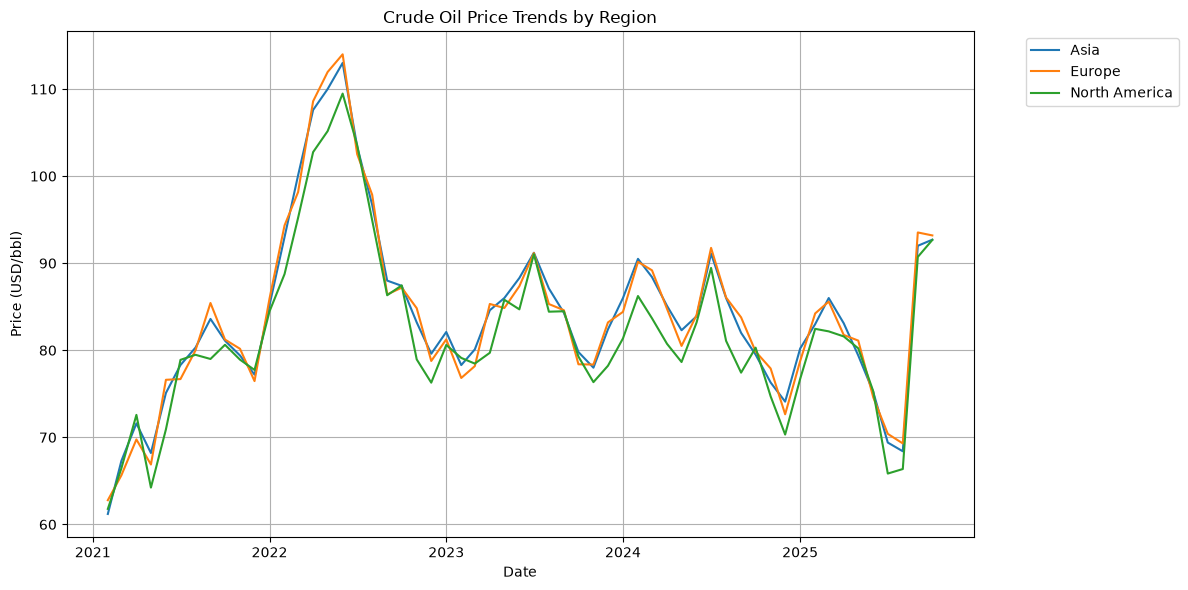

In [ ]:
import matplotlib.pyplot as plt

filtered_df = df.query("date > 2021")

plt.rcParams["figure.figsize"] = (12, 6)

for region_name, group in filtered_df.groupby('region'):
    plt.plot(group['date'], group['price_usd_bbl'], label=region_name)


plt.title('Crude Oil Price Trends by Region')
plt.xlabel('Date')
plt.ylabel('Price (USD/bbl)')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


plt.grid(True)

plt.tight_layout()

### Monthly Change

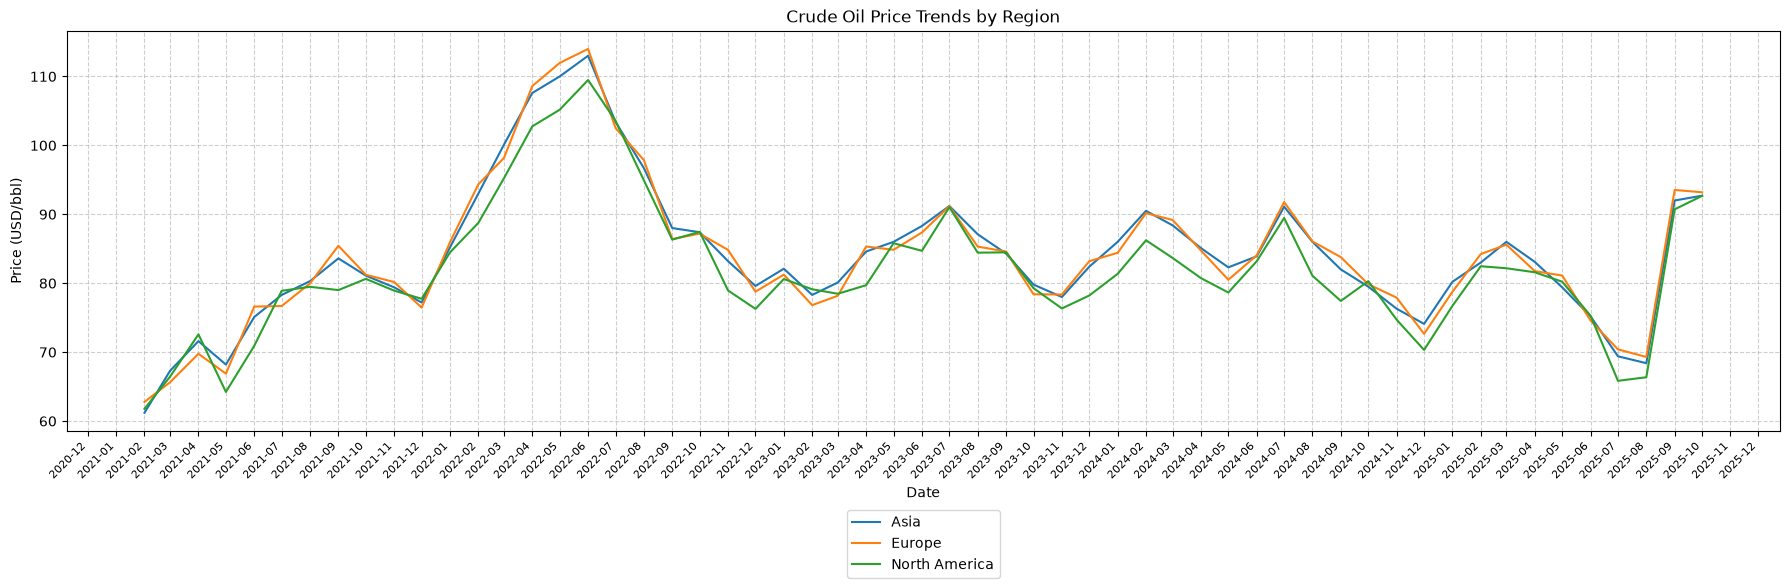

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates  

filtered_df = df.query("date > 2021")

fig, ax = plt.subplots(figsize=(18, 6))

for region_name, group in filtered_df.groupby('region'):
    ax.plot(group['date'], group['price_usd_bbl'], label=region_name)


ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.autofmt_xdate()
plt.xticks(fontsize=8, rotation=45)


plt.title('Crude Oil Price Trends by Region')
plt.xlabel('Date')
plt.ylabel('Price (USD/bbl)')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=1)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()


## Data Interpretation
The global average oil price increased by approximately $20 per barrel between March and April 2026. This surge was led by Europe, which saw the sharpest increase at $35 per barrel. This upward trend persisted into May, pushing the global average to $105 per barrel, while European prices broke past the $120 mark.
In contrast, the price increase in the Asian market was relatively moderate. While Asian prices did rise by around $20 per barrel in March, the subsequent growth trajectory remained gradual. This stability was likely because several Asian countries managed to secure oil supplies from Russia; by maintaining these robust inventories, they avoided the need to buy oil at high spot prices, unlike European countries. 

